Task 5 - Clustering Models

1. Perform K-Means clustering on a customer segmentation dataset (e.g., Mall Customers).

2. Determine the optimal number of clusters using the Elbow method/Silhoutte Score.

3. Visualize the clusters and interpret them.

4. Apply Hierarchical clustering on the same dataset.

5. Plot the dendrogram and explain how to choose the number of clusters.

6. Compare results from K-Means and Hierarchical clustering. Which gives more interpretable clusters?

In [160]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
import math
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [80]:
data = pd.read_csv("Mall_Customers.csv")

In [81]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [83]:
data['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [84]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: >

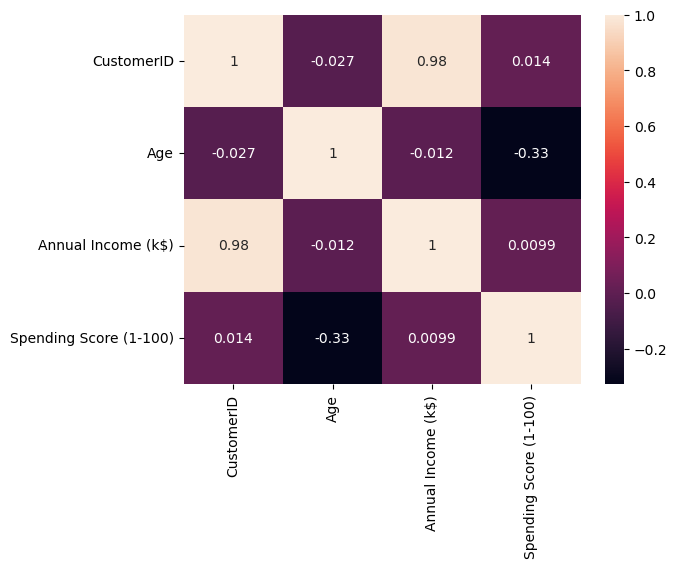

In [85]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

Genre
Female    59.250000
Male      62.227273
Name: Annual Income (k$), dtype: float64


<Axes: xlabel='Genre'>

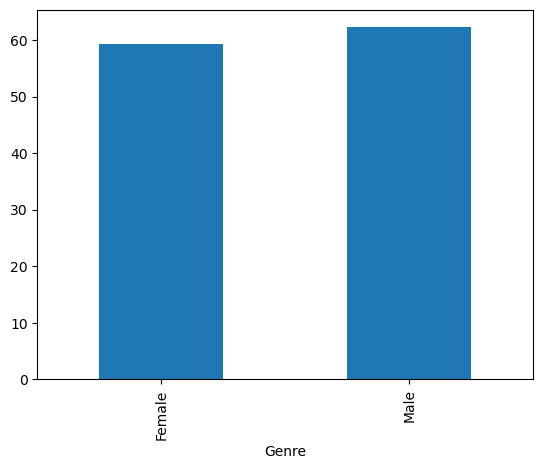

In [86]:
print(data.groupby('Genre')['Annual Income (k$)'].mean())
data.groupby('Genre')['Annual Income (k$)'].mean().plot(kind='bar')

<Axes: xlabel='Genre'>

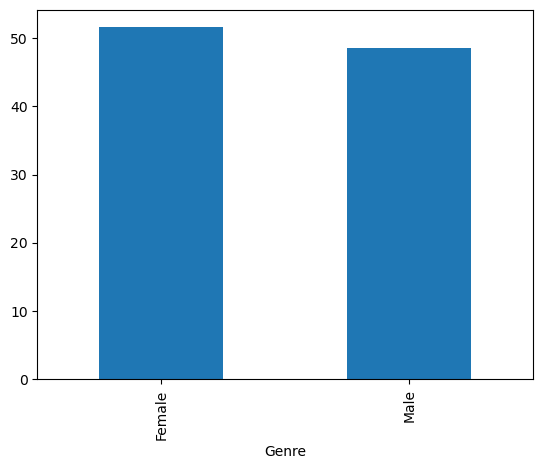

In [87]:
data.groupby('Genre')['Spending Score (1-100)'].mean().plot(kind='bar')

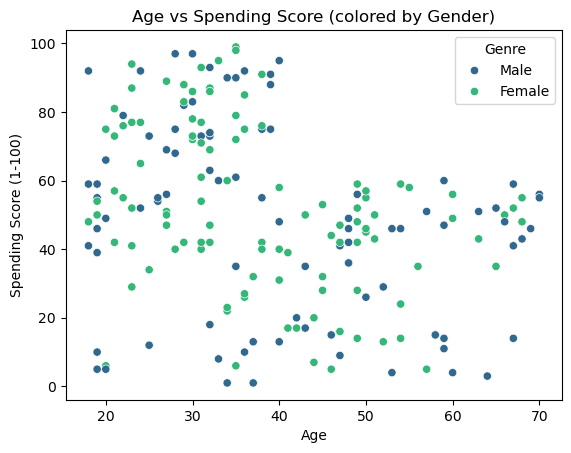

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: coloring points by 'Gender'
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Genre', data=data, palette='viridis')

plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('Age vs Spending Score (colored by Gender)')
plt.show()


In [117]:
encoder = LabelEncoder()
encoder.fit(data['Genre'])
data['Genre'] = encoder.transform(data['Genre'])
data['Genre'] = encoder.transform(data['Genre'])
data
x=data
y=data['Age']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.2,random_state = 0)

scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train),columns=x_test.columns)
x_test_scaled = pd.DataFrame(scaler.fit_transform(x_test),columns=x_test.columns)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_train_scaled)
x_pca[:,1]


array([-6.52927745e-01,  2.65615563e-02, -5.67827304e-01,  5.19903854e-01,
       -2.63473427e-01, -2.44355973e-01, -2.79661063e+00,  4.05032815e-01,
       -5.36173597e-01,  1.57310542e+00, -3.81325862e-01,  3.98323526e-01,
       -1.67172443e-01,  7.84309946e-01,  1.02881161e+00, -1.48751037e+00,
       -2.57801488e+00, -9.86139443e-01, -1.42601977e+00, -3.51593832e-01,
        3.78133163e-01, -2.40606121e-01,  1.54997836e+00,  1.71893110e+00,
        9.89154555e-01, -7.66748522e-01, -4.42328401e-01,  1.78813563e+00,
        2.37514820e-01, -3.16111086e-01,  1.01848327e+00, -1.01062041e+00,
        6.53657736e-01, -3.06665595e-01, -6.94551768e-01, -4.10414408e-01,
       -1.63976833e+00, -1.24856167e+00,  1.68100040e-01,  1.20455545e+00,
        7.10243884e-01, -1.68157482e-01, -4.67654460e-01,  1.21640508e+00,
       -1.87175197e+00, -1.04958795e+00, -1.08504967e-01, -1.08901312e+00,
       -1.19476305e+00,  6.86534773e-01,  8.91652668e-01, -2.63489019e+00,
       -1.08288880e+00, -

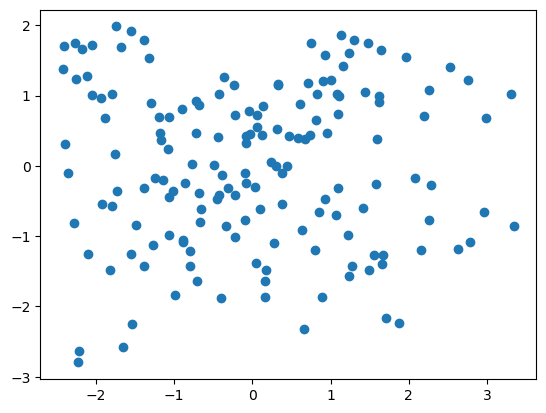

In [119]:
# [].scatterplot(x_pca[:,0],x_pca[:,1])?
plt.scatter(x=x_pca[:,0],y=x_pca[:,1])

In [120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


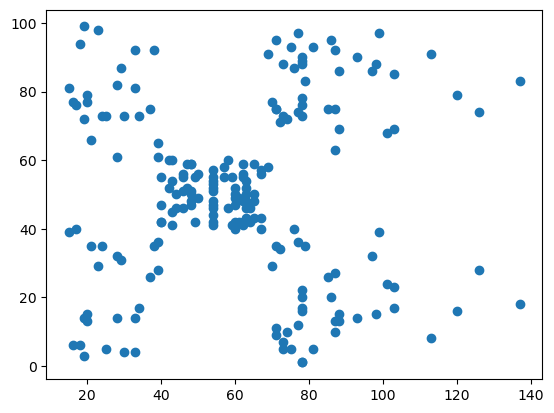

In [121]:
plt.scatter(x=data['Annual Income (k$)'],y=data['Spending Score (1-100)'])

c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

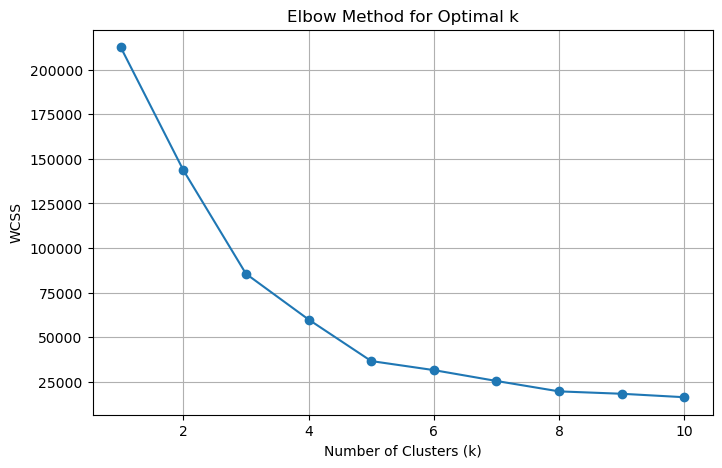

In [ ]:
# y=data['Age']
x= data.drop(columns=['Age','CustomerID','Genre'])
x
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.2,random_state = 0)
wcss = []  # Within-cluster sum of squares
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()



In [151]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    preds = kmeans.fit_predict(x_train)
    score = silhouette_score(x_train, preds)
    print(f"For n_clusters = {k}, Silhouette Score = {score:.3f}")


For n_clusters = 2, Silhouette Score = 0.289
For n_clusters = 3, Silhouette Score = 0.468
For n_clusters = 4, Silhouette Score = 0.497
For n_clusters = 5, Silhouette Score = 0.556
For n_clusters = 6, Silhouette Score = 0.456
For n_clusters = 7, Silhouette Score = 0.462


c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


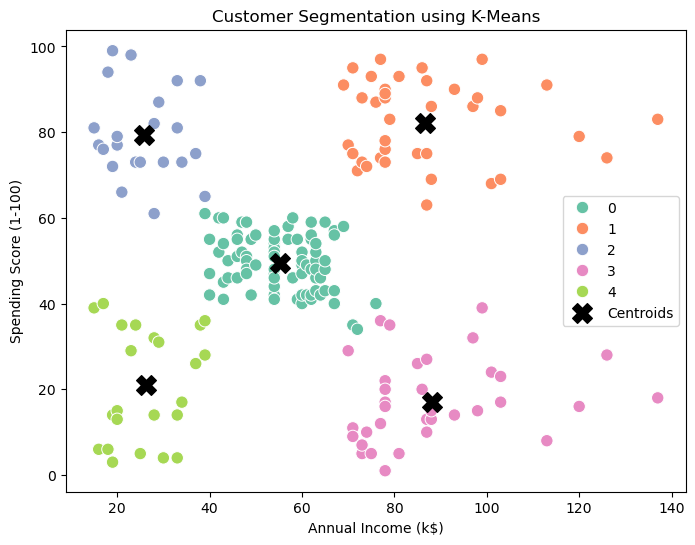

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
data['Cluster'] = kmeans.fit_predict(x)

# Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=data, palette='Set2', s=80)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],s=200, c='black', marker='X', label='Centroids')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.show()

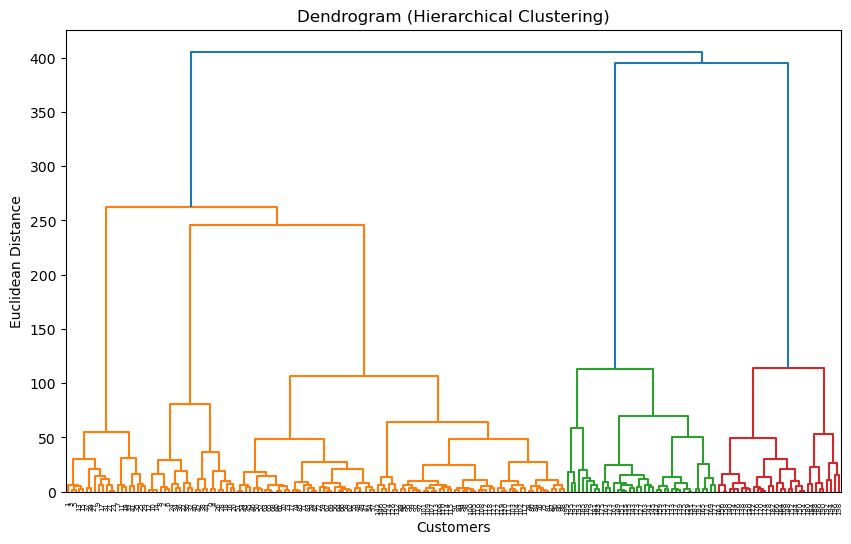

In [164]:
# Perform linkage for dendrogram
linked = linkage(x, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()


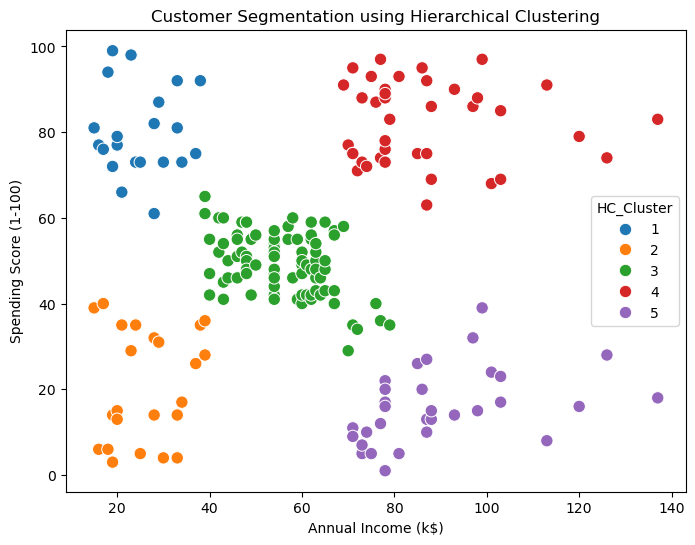

In [167]:
# Choose 5 clusters (based on dendrogram)
clusters_hier = fcluster(linked, 5, criterion='maxclust')
data['HC_Cluster'] = clusters_hier

# Visualize hierarchical clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='HC_Cluster', data=data, palette='tab10', s=80)
plt.title('Customer Segmentation using Hierarchical Clustering')
plt.show()


In [168]:
comparison = data[['Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'HC_Cluster']]
print(comparison.head())


   Annual Income (k$)  Spending Score (1-100)  Cluster  HC_Cluster
0                  15                      39        4           2
1                  15                      81        2           1
2                  16                       6        4           2
3                  16                      77        2           1
4                  17                      40        4           2
